## Amazon Product Reviews NLP + Time Series Forecasting Project

##  Import Libraries

In [38]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.sentiment.vader import SentimentIntensityAnalyzer

from prophet import Prophet

from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import shap
import plotly.express as px
import plotly.graph_objects as go

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings("ignore")


## Data Loading

In [39]:

df = pd.read_csv("D:\IMARTICUS\DATASETS\Capstone Project 1\RESOURCES\HP 1\DATA\Amazon_Product_Reviews_with_Sales_1.csv")
df.head(2)


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sales
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,31-08-2015,8166
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,31-08-2015,3218


## Data Cleaning

In [40]:

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_review'] = df['review_body'].apply(clean_text)
df['date'] = pd.to_datetime(df['review_date'])
df = df.dropna()


## Exploratory Data Analysis (EDA)

In [41]:
df.describe()

,customer_id,product_parent,star_rating,helpful_votes,total_votes,sales,date
count,3.084000e+04,30840.0,30840.000000,30840.000000,30840.000000,30840.000000,30840
mean,2.470843e+07,2693241.0,4.336316,0.686543,0.894942,5064.289559,2015-03-11 10:55:22.645914624
min,1.134600e+04,2693241.0,1.000000,0.000000,0.000000,100.000000,2014-10-03 00:00:00
25%,1.150586e+07,2693241.0,4.000000,0.000000,0.000000,2598.750000,2015-01-04 00:00:00
50%,2.294012e+07,2693241.0,5.000000,0.000000,0.000000,5058.000000,2015-02-16 00:00:00
75%,4.008417e+07,2693241.0,5.000000,0.000000,0.000000,7536.000000,2015-05-17 00:00:00
max,5.309351e+07,2693241.0,5.000000,3720.000000,3875.000000,9999.000000,2015-08-31 00:00:00
std,1.611152e+07,0.0,1.120569,30.746359,32.359474,2851.738699,NaN


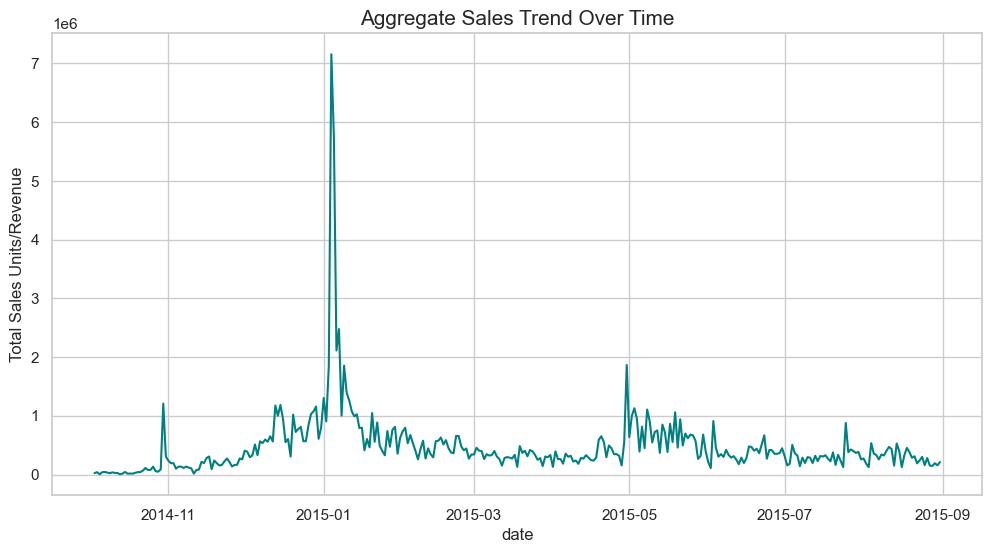

In [42]:
# 1. Sales Trend Over Time

plt.figure()
df_trend = df.groupby('date')['sales'].sum().reset_index()
sns.lineplot(data=df_trend, x='date', y='sales', color='teal')
plt.title('Aggregate Sales Trend Over Time', fontsize=15)
plt.ylabel('Total Sales Units/Revenue')
plt.show()


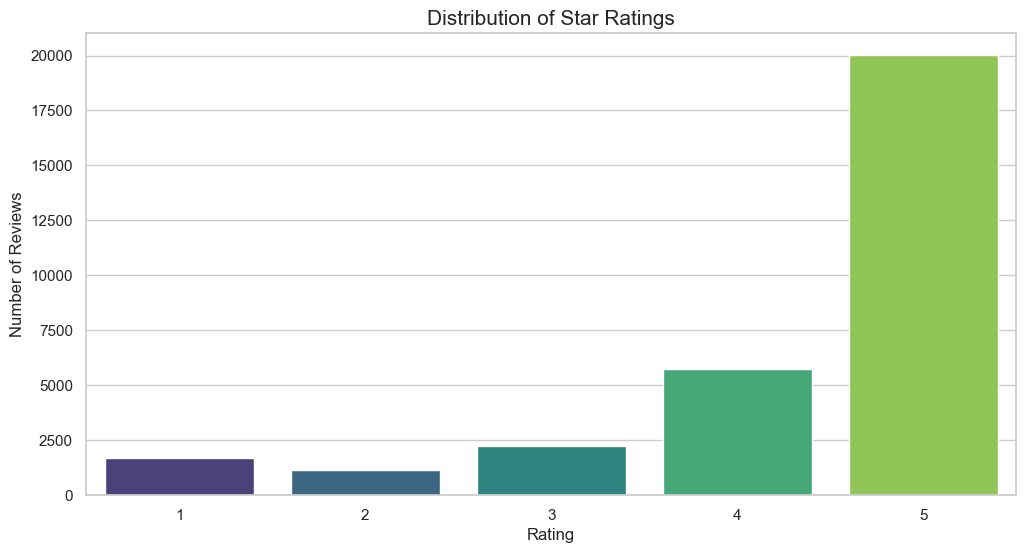

In [43]:
# 2. Distribution of Star Ratings

plt.figure()
sns.countplot(data=df, x='star_rating', palette='viridis')
plt.title('Distribution of Star Ratings', fontsize=15)
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()


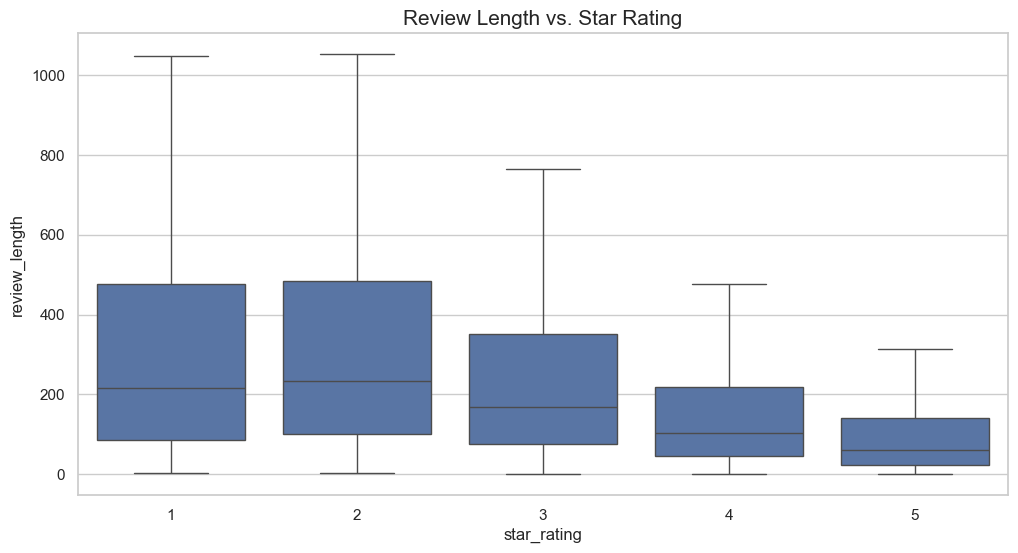

In [44]:
# 3. Review Length vs. Rating 

df['review_length'] = df['review_body'].astype(str).apply(len)
plt.figure()
sns.boxplot(data=df, x='star_rating', y='review_length', showfliers=False)
plt.title('Review Length vs. Star Rating', fontsize=15)
plt.show()


## Sentiment Analysis

In [45]:

analyzer = SentimentIntensityAnalyzer()
df['sentiment'] = df['clean_review'].apply(lambda x: analyzer.polarity_scores(x)['compound'])


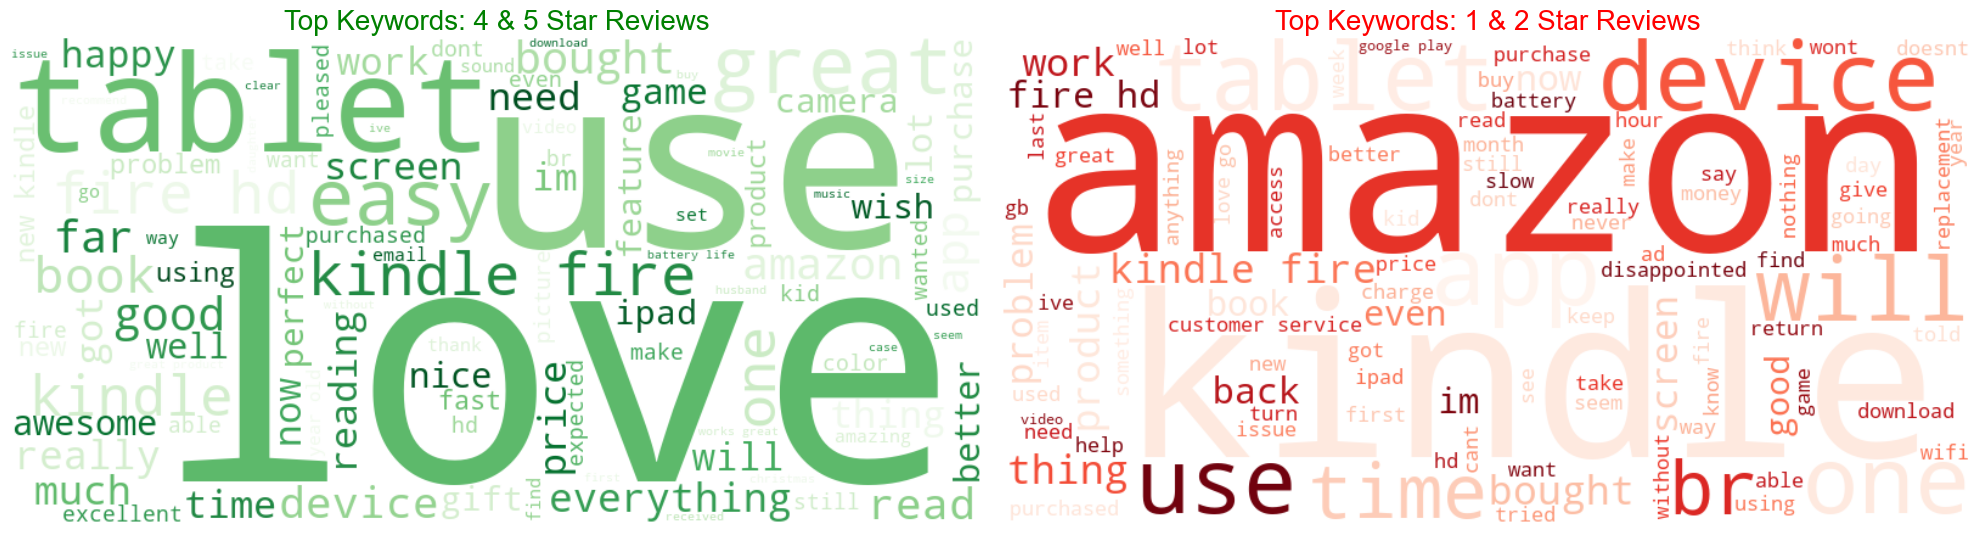

In [46]:
from wordcloud import WordCloud

# 1. Split the data into High and Low ratings
pos_reviews = " ".join(df[df['star_rating'] >= 4]['clean_review'])
neg_reviews = " ".join(df[df['star_rating'] <= 2]['clean_review'])

# 2. Generate WordClouds
wc_params = {'width': 800, 'height': 400, 'background_color': 'white', 'max_words': 100}

wc_pos = WordCloud(**wc_params, colormap='Greens').generate(pos_reviews)
wc_neg = WordCloud(**wc_params, colormap='Reds').generate(neg_reviews)

# 3. Plotting Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Positive WordCloud
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Top Keywords: 4 & 5 Star Reviews', fontsize=20, color='green')
axes[0].axis('off')

# Negative WordCloud
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Top Keywords: 1 & 2 Star Reviews', fontsize=20, color='red')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## TF-IDF Feature Engineering

In [47]:

tfidf = TfidfVectorizer(max_features=300, stop_words='english')
X_tfidf = tfidf.fit_transform(df['clean_review']).toarray()


## Time-Series Aggregation

In [48]:

ts = df.groupby('date').agg({
    'sales':'sum',
    'sentiment':'mean'
}).reset_index()

ts.head(2)


,date,sales,sentiment
0,2014-10-03,25525,0.899340
1,2014-10-04,41128,-0.083983


## Time-Series Feature Engineering

In [49]:

ts['lag1'] = ts['sales'].shift(1)
ts['lag7'] = ts['sales'].shift(7)
ts['rolling_mean'] = ts['sales'].rolling(7).mean()

ts = ts.dropna()
ts.head(2)


,date,sales,sentiment,lag1,lag7,rolling_mean
7,2014-10-10,38207,0.422025,24530.0,25525.0,33007.428571
8,2014-10-11,28649,0.132600,38207.0,41128.0,31224.714286


## Train/Test Split

In [50]:
def sequential_split(data, train_size=0.8):
    
    split_index = int(len(data) * train_size)
    
    train = data.iloc[:split_index]
    test = data.iloc[split_index:]
    
    return train, test

train, test = sequential_split(ts, train_size=0.8)

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 260
Test size: 66


## Prophet Model

In [51]:

prophet_train = train.rename(columns={"date":"ds","sales":"y"})

model_prophet = Prophet()
model_prophet.fit(prophet_train)

future = model_prophet.make_future_dataframe(periods=len(test))

forecast = model_prophet.predict(future)

prophet_pred = forecast["yhat"].iloc[-len(test):].values

forecast[['ds','yhat']].head(2)


21:17:43 - cmdstanpy - INFO - Chain [1] start processing
21:17:44 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
0,2014-10-10,-40855.426579
1,2014-10-11,18221.590009


## XGBoost Model

In [52]:
features = ["lag1","lag7","rolling_mean","sentiment"]

X_train = train[features]
y_train = train["sales"]

X_test = test[features]
y_test = test["sales"]

model_xgb = XGBRegressor(n_estimators=200)

model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)


## LSTM Model

In [53]:

scaler = MinMaxScaler()

scaled = scaler.fit_transform(ts['sales'].values.reshape(-1,1))

window=30

X=[]
y=[]

for i in range(window,len(scaled)):
    X.append(scaled[i-window:i])
    y.append(scaled[i])

X=np.array(X)
y=np.array(y)

split_lstm=int(len(X)*0.8)

X_train_lstm=X[:split_lstm]
X_test_lstm=X[split_lstm:]

y_train_lstm=y[:split_lstm]
y_test_lstm=y[split_lstm:]

model_lstm=Sequential()
model_lstm.add(LSTM(50,activation='relu',input_shape=(window,1)))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam',loss='mse')

model_lstm.fit(X_train_lstm,y_train_lstm,epochs=10,batch_size=16)

lstm_pred=model_lstm.predict(X_test_lstm)

lstm_pred=scaler.inverse_transform(lstm_pred)


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0101
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0079
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0071
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0070
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0067
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0063
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0065
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0061
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0061
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 361ms/step


## Time-Series Cross Validation

In [54]:

tscv=TimeSeriesSplit(n_splits=5)

scores=[]

for train_index,test_index in tscv.split(ts):

    train_cv=ts.iloc[train_index]
    test_cv=ts.iloc[test_index]

    model=XGBRegressor(n_estimators=200)
    model.fit(train_cv[features],train_cv['sales'])

    pred=model.predict(test_cv[features])

    rmse=np.sqrt(mean_squared_error(test_cv['sales'],pred))

    scores.append(rmse)

scores


[np.float64(1348582.4386339902),
 np.float64(140593.0333409163),
 np.float64(652420.7086351566),
 np.float64(151409.62907292257),
 np.float64(125465.16890356463)]

## Hybrid Model

In [55]:

ts['prophet_pred'] = forecast['yhat'][:len(ts)]
ts['residual'] = ts['sales'] - ts['prophet_pred']

X = ts[['prophet_pred','sentiment']]
y = ts['sales']

model_hybrid = XGBRegressor()
model_hybrid.fit(X,y)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [56]:
hybrid_pred = model_hybrid.predict(X)

mae = mean_absolute_error(y, hybrid_pred)
rmse = np.sqrt(mean_squared_error(y, hybrid_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 14794.9443359375
RMSE: 20746.014557017934


## Model Evaluation & Automated Model Selection

In [57]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape


prophet_pred = forecast['yhat'].iloc[-len(test):].values

hybrid_pred = hybrid_pred[-len(y_test):]

prophet_mae, prophet_rmse, prophet_mape = evaluate(y_test, prophet_pred)
xgb_mae, xgb_rmse, xgb_mape = evaluate(y_test, xgb_pred)
hybrid_mae, hybrid_rmse, hybrid_mape = evaluate(y_test, hybrid_pred)

results = pd.DataFrame({
    'Model': ['Prophet', 'XGBoost', 'Hybrid'],
    'MAE': [prophet_mae, xgb_mae, hybrid_mae],
    'RMSE': [prophet_rmse, xgb_rmse, hybrid_rmse],
    'MAPE (%)': [prophet_mape, xgb_mape, hybrid_mape]
})

results


,Model,MAE,RMSE,MAPE (%)
0,Prophet,119330.160728,155903.732165,46.053168
1,XGBoost,93862.687500,122407.148549,38.681433
2,Hybrid,10932.043945,15306.960508,4.468765


## Forecast Confidence Intervals

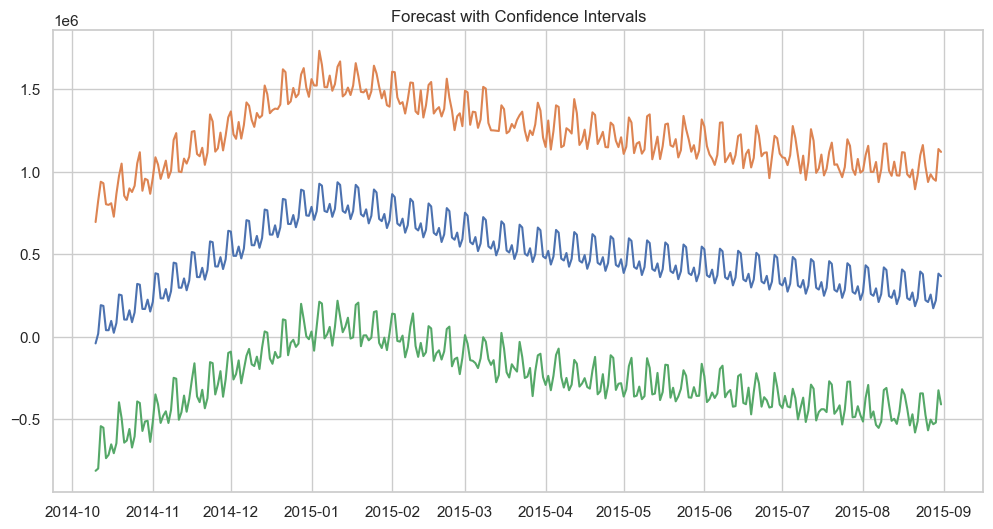

In [58]:

plt.figure()
plt.plot(forecast['ds'],forecast['yhat'])
plt.plot(forecast['ds'],forecast['yhat_upper'])
plt.plot(forecast['ds'],forecast['yhat_lower'])
plt.title("Forecast with Confidence Intervals")
plt.show()


## Interactive Plotly Dashboard

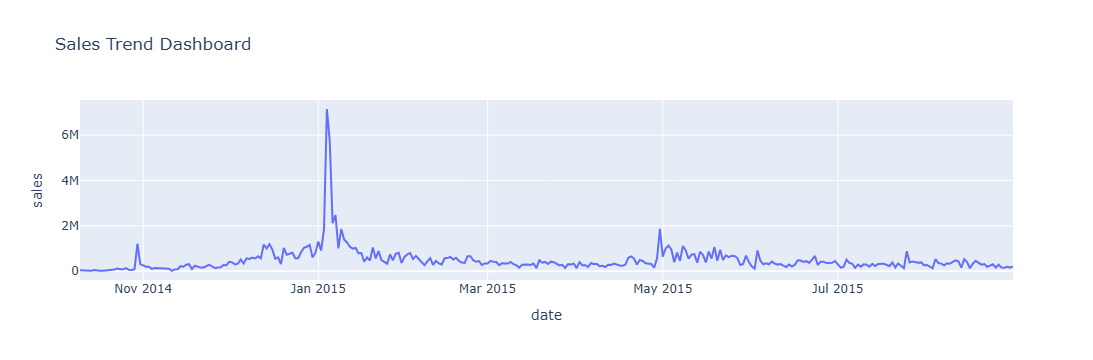

In [59]:

fig = px.line(ts, x='date', y='sales', title='Sales Trend Dashboard')
fig.show()


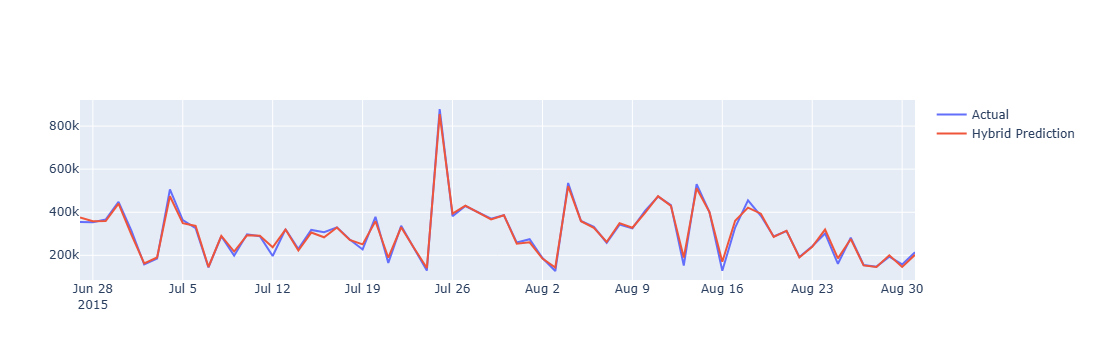

In [60]:

fig = go.Figure()

fig.add_trace(go.Scatter(x=test['date'],y=y_test,name='Actual'))
fig.add_trace(go.Scatter(x=test['date'],y=hybrid_pred,name='Hybrid Prediction'))

fig.show()


## 24-Month Forecast (Hybrid Model)

In [26]:

future_forecast = forecast.tail(730)
future_forecast[['ds','yhat']].head()


,ds,yhat
0,2014-10-10,-40855.426579
1,2014-10-11,18221.590009
2,2014-10-12,191008.027286
3,2014-10-13,186208.552900
4,2014-10-14,39312.225858


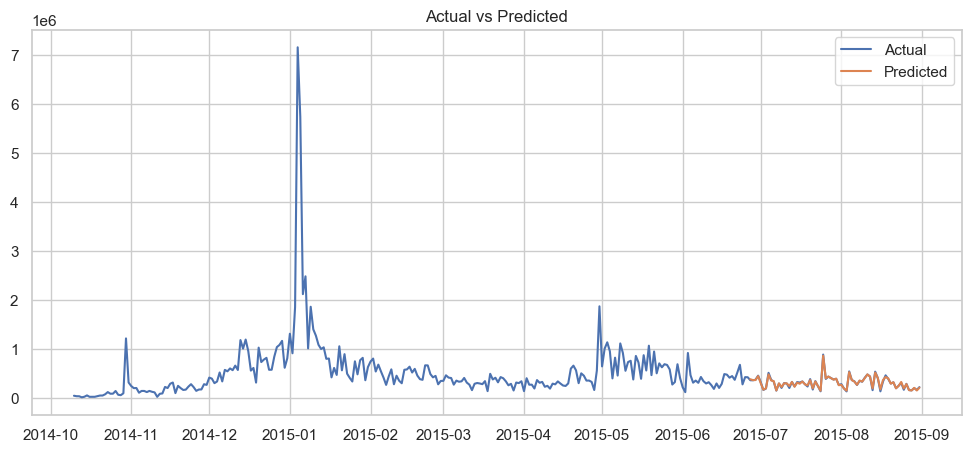

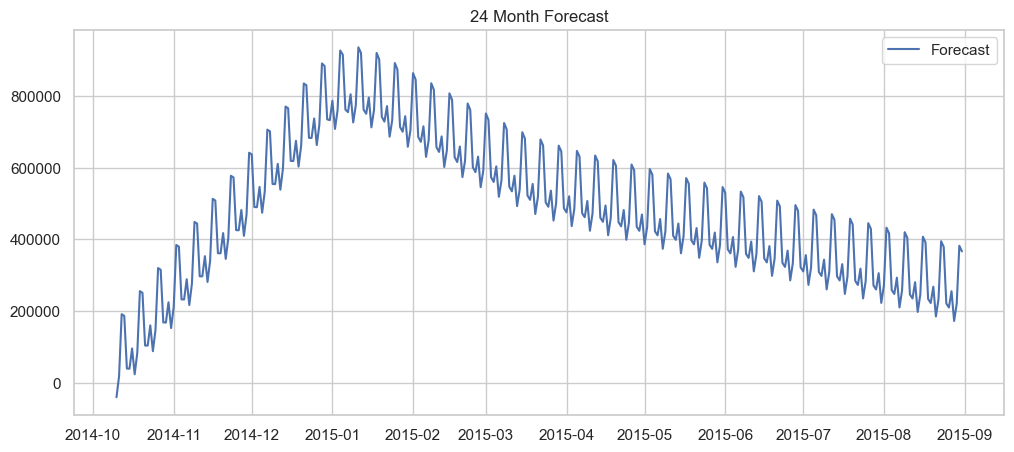

In [29]:

plt.figure(figsize=(12,5))
plt.plot(ts['date'], ts['sales'], label='Actual')
plt.plot(test['date'], hybrid_pred, label='Predicted')

plt.legend()
plt.title('Actual vs Predicted')
plt.show()

plt.figure(figsize=(12,5))
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')

plt.title('24 Month Forecast')
plt.legend()
plt.show()


## Product-Level 36-Month Forecast

20:29:41 - cmdstanpy - INFO - Chain [1] start processing
20:30:05 - cmdstanpy - INFO - Chain [1] done processing


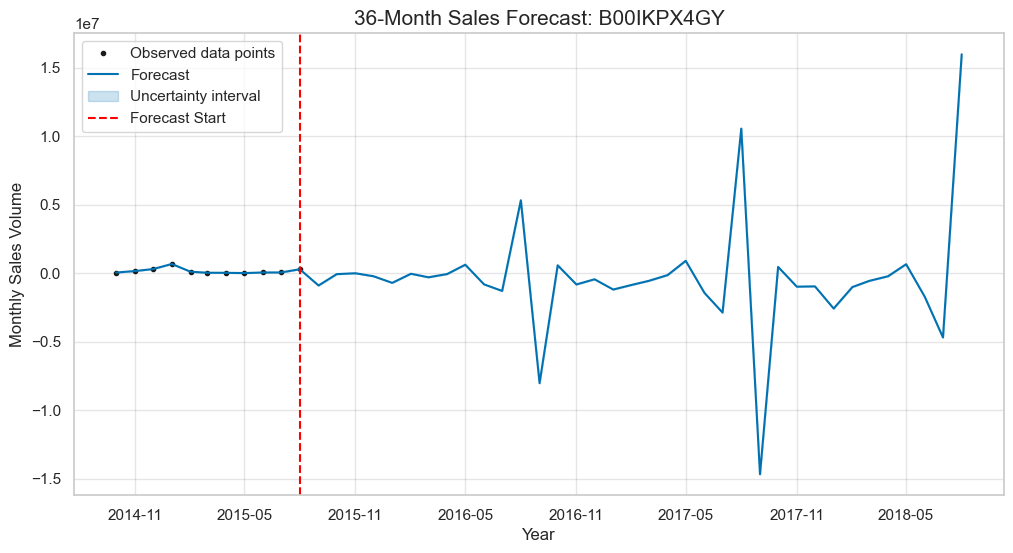

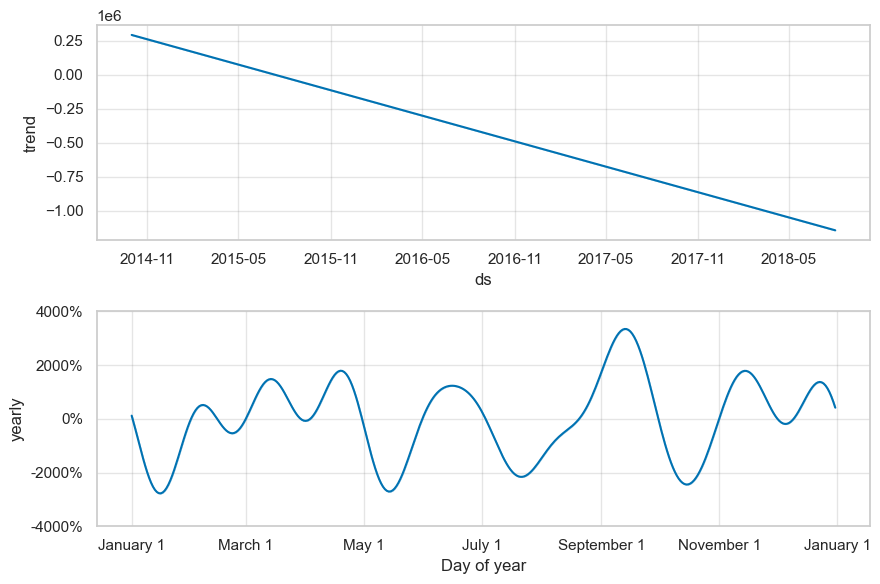

In [32]:

# 1. Select a Product (Change 'Product_A' to an actual ID from your df)
# Assuming your original dataframe is 'df'
target_product = df['product_id'].unique()[0] 
product_df = df[df['product_id'] == target_product].copy()

# 2. Prepare for Prophet (Monthly Aggregation)
product_df['date'] = pd.to_datetime(product_df['date'])
product_ts = product_df.resample('MS', on='date')['sales'].sum().reset_index()
product_ts.columns = ['ds', 'y']

# 3. Initialize and Fit the Model
# We enable yearly seasonality as it's crucial for a 3-year outlook
model_36 = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=False, 
    daily_seasonality=False,
    seasonality_mode='multiplicative' # Better for growing sales trends
)
model_36.fit(product_ts)

# 4. Create 36-Month Future Horizon
future_36 = model_36.make_future_dataframe(periods=36, freq='MS')
forecast_36 = model_36.predict(future_36)

# 5. Visualization
plt.figure(figsize=(12, 6))
model_36.plot(forecast_36, ax=plt.gca())
plt.title(f'36-Month Sales Forecast: {target_product}', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Monthly Sales Volume')
plt.axvline(x=product_ts['ds'].iloc[-1], color='red', linestyle='--', label='Forecast Start')
plt.legend()
plt.show()

# 6. View Trend Components
model_36.plot_components(forecast_36)
plt.show()

## 36-Month Forecast with a sentiment lag

20:30:11 - cmdstanpy - INFO - Chain [1] start processing
20:30:11 - cmdstanpy - INFO - Chain [1] done processing


Final Model MAE (7-Day Lag): 720920.23


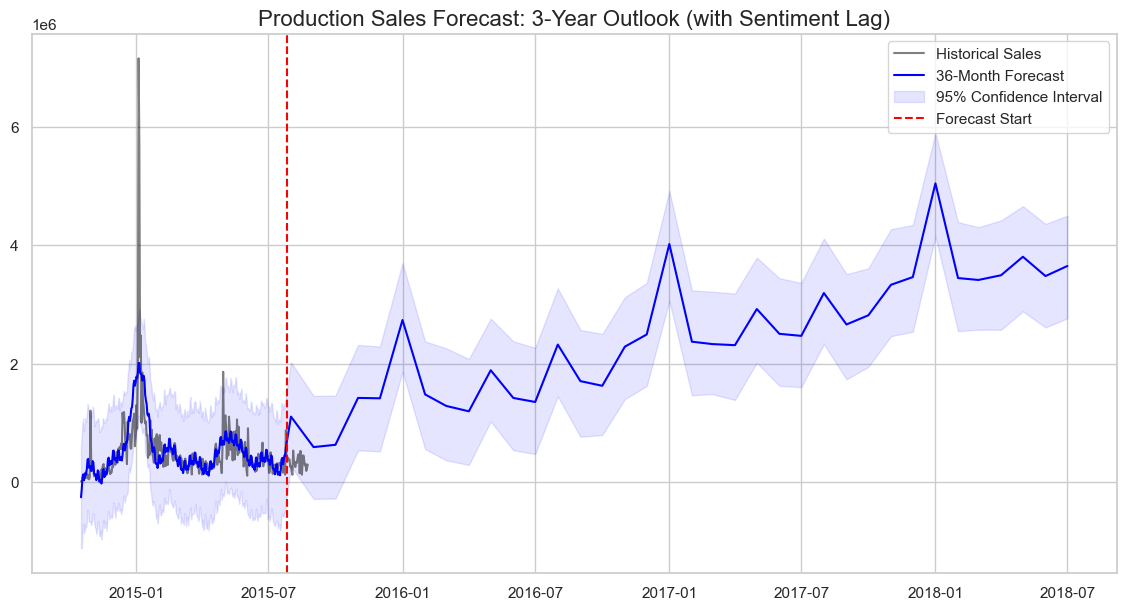

In [33]:

# Feature Engineering: 7-Day Sentiment Lag
df_final = ts.rename(columns={'date': 'ds', 'sales': 'y'})
df_final['sentiment_lag'] = df_final['sentiment'].shift(7)

df_final = df_final.dropna()

train = df_final.iloc[:-30]
test = df_final.iloc[-30:]

model_lag = Prophet(yearly_seasonality=True, interval_width=0.95)
model_lag.add_regressor('sentiment_lag')
model_lag.fit(train)

forecast_test = model_lag.predict(test)
mae_lag = mean_absolute_error(test['y'], forecast_test['yhat'])
print(f"Final Model MAE (7-Day Lag): {mae_lag:.2f}")

# 36-Month Future Forecast
future_36 = model_lag.make_future_dataframe(periods=36, freq='MS')
future_36['sentiment_lag'] = df_final['sentiment_lag'].mean() 

forecast_36 = model_lag.predict(future_36)

plt.figure(figsize=(14, 7))

plt.plot(df_final['ds'], df_final['y'], label='Historical Sales', color='black', alpha=0.5)
plt.plot(forecast_36['ds'], forecast_36['yhat'], label='36-Month Forecast', color='blue')

plt.fill_between(forecast_36['ds'], forecast_36['yhat_lower'], forecast_36['yhat_upper'], 
                 color='blue', alpha=0.1, label='95% Confidence Interval')

plt.axvline(x=test['ds'].iloc[0], color='red', linestyle='--', label='Forecast Start')
plt.title('Production Sales Forecast: 3-Year Outlook (with Sentiment Lag)', fontsize=16)
plt.legend()
plt.show()


20:30:16 - cmdstanpy - INFO - Chain [1] start processing
20:30:16 - cmdstanpy - INFO - Chain [1] done processing
20:30:16 - cmdstanpy - INFO - Chain [1] start processing
20:30:16 - cmdstanpy - INFO - Chain [1] done processing
20:30:17 - cmdstanpy - INFO - Chain [1] start processing
20:30:17 - cmdstanpy - INFO - Chain [1] done processing
20:30:17 - cmdstanpy - INFO - Chain [1] start processing
20:30:17 - cmdstanpy - INFO - Chain [1] done processing
20:30:17 - cmdstanpy - INFO - Chain [1] start processing
20:30:18 - cmdstanpy - INFO - Chain [1] done processing
20:30:18 - cmdstanpy - INFO - Chain [1] start processing
20:30:18 - cmdstanpy - INFO - Chain [1] done processing
20:30:18 - cmdstanpy - INFO - Chain [1] start processing
20:30:18 - cmdstanpy - INFO - Chain [1] done processing
20:30:19 - cmdstanpy - INFO - Chain [1] start processing
20:30:19 - cmdstanpy - INFO - Chain [1] done processing
20:30:19 - cmdstanpy - INFO - Chain [1] start processing
20:30:19 - cmdstanpy - INFO - Chain [1]

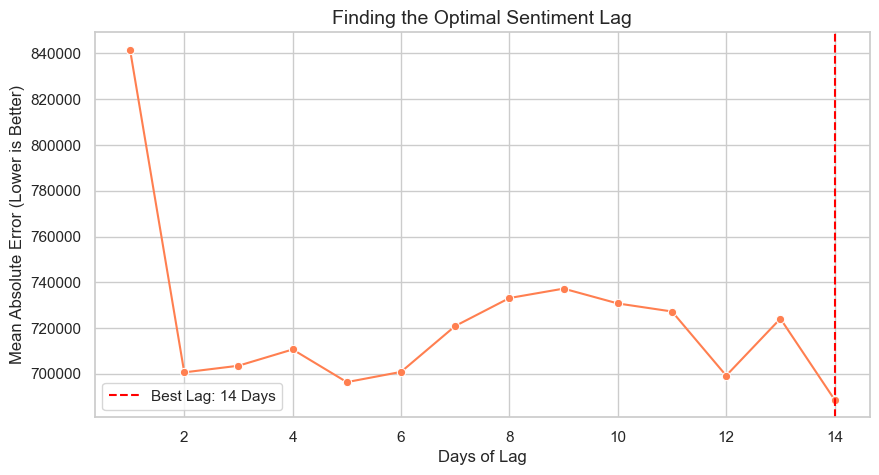

Optimization Complete! The most predictive power comes from a 14-day lag.


In [34]:
results = []
lag_range = range(1, 15)  # Testing lags from 1 to 14 days

for lag in lag_range:
    # 1. Apply Lag
    df_temp = ts.rename(columns={'date': 'ds', 'sales': 'y'})
    df_temp['lag_feature'] = df_temp['sentiment'].shift(lag)
    df_temp = df_temp.dropna()
    
    # 2. Split
    train_tmp = df_temp.iloc[:-30]
    test_tmp = df_temp.iloc[-30:]
    
    # 3. Fit & Predict
    m_tmp = Prophet(yearly_seasonality=True, daily_seasonality=False)
    m_tmp.add_regressor('lag_feature')
    m_tmp.fit(train_tmp, iter=500) # iter limited for speed
    
    forecast_tmp = m_tmp.predict(test_tmp)
    mae = mean_absolute_error(test_tmp['y'], forecast_tmp['yhat'])
    
    results.append({'lag': lag, 'mae': mae})

# Convert to DataFrame for analysis
tuning_results = pd.DataFrame(results)
best_lag = tuning_results.loc[tuning_results['mae'].idxmin()]

# 4. Visualize the "Elbow"
plt.figure(figsize=(10, 5))
sns.lineplot(data=tuning_results, x='lag', y='mae', marker='o', color='coral')
plt.axvline(x=best_lag['lag'], color='red', linestyle='--', label=f"Best Lag: {int(best_lag['lag'])} Days")
plt.title('Finding the Optimal Sentiment Lag', fontsize=14)
plt.xlabel('Days of Lag')
plt.ylabel('Mean Absolute Error (Lower is Better)')
plt.legend()
plt.show()

print(f"Optimization Complete! The most predictive power comes from a {int(best_lag['lag'])}-day lag.")

20:30:26 - cmdstanpy - INFO - Chain [1] start processing
20:30:26 - cmdstanpy - INFO - Chain [1] done processing


Final Model MAE (14-Day Lag): 688703.10


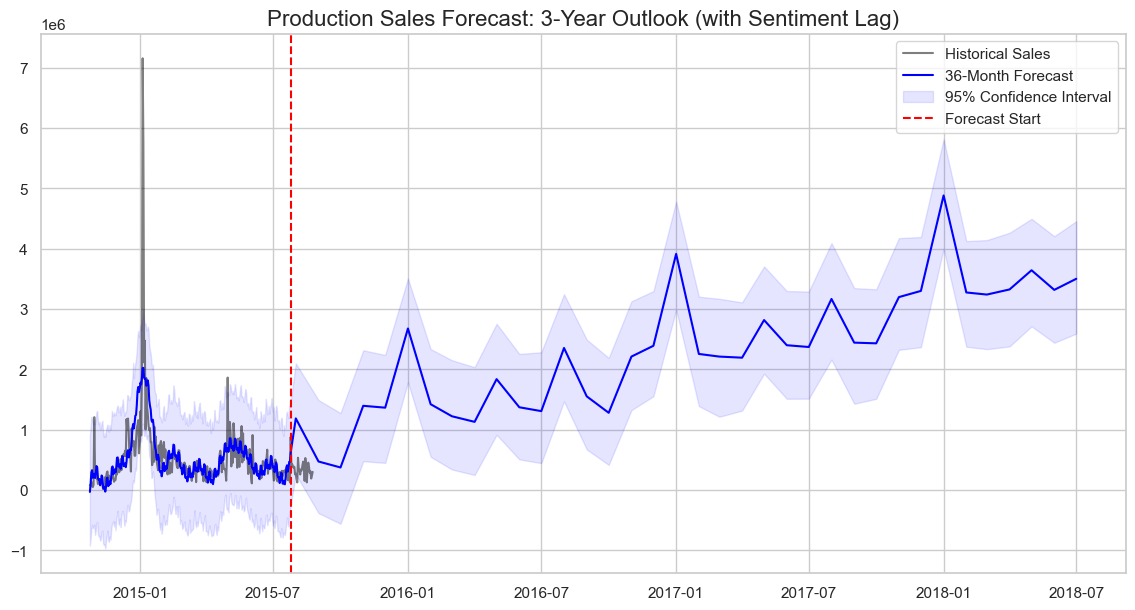

In [35]:

# Feature Engineering: 14-Day Sentiment Lag
df_final = ts.rename(columns={'date': 'ds', 'sales': 'y'})
df_final['sentiment_lag'] = df_final['sentiment'].shift(14)

df_final = df_final.dropna()

train = df_final.iloc[:-30]
test = df_final.iloc[-30:]

model_lag = Prophet(yearly_seasonality=True, interval_width=0.95)
model_lag.add_regressor('sentiment_lag')
model_lag.fit(train)

forecast_test = model_lag.predict(test)
mae_lag = mean_absolute_error(test['y'], forecast_test['yhat'])
print(f"Final Model MAE (14-Day Lag): {mae_lag:.2f}")

# 36-Month Future Forecast
future_36 = model_lag.make_future_dataframe(periods=36, freq='MS')
future_36['sentiment_lag'] = df_final['sentiment_lag'].mean() 

forecast_36 = model_lag.predict(future_36)

plt.figure(figsize=(14, 7))

plt.plot(df_final['ds'], df_final['y'], label='Historical Sales', color='black', alpha=0.5)
plt.plot(forecast_36['ds'], forecast_36['yhat'], label='36-Month Forecast', color='blue')

plt.fill_between(forecast_36['ds'], forecast_36['yhat_lower'], forecast_36['yhat_upper'], 
                 color='blue', alpha=0.1, label='95% Confidence Interval')

plt.axvline(x=test['ds'].iloc[0], color='red', linestyle='--', label='Forecast Start')
plt.title('Production Sales Forecast: 3-Year Outlook (with Sentiment Lag)', fontsize=16)
plt.legend()
plt.show()


In [36]:
# Create a simple summary for stakeholders
final_forecast_table = forecast_36[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)
final_forecast_table.columns = ['Month', 'Projected Sales', 'Min Expected', 'Max Expected']
print("--- NEXT 12 MONTHS FORECAST SUMMARY ---")
print(final_forecast_table.to_string(index=False))

--- NEXT 12 MONTHS FORECAST SUMMARY ---
     Month  Projected Sales  Min Expected  Max Expected
2017-08-01     3.168011e+06  2.162888e+06  4.093696e+06
2017-09-01     2.444067e+06  1.431193e+06  3.348298e+06
2017-10-01     2.432466e+06  1.512524e+06  3.327599e+06
2017-11-01     3.198908e+06  2.324553e+06  4.176450e+06
2017-12-01     3.301348e+06  2.368664e+06  4.195328e+06
2018-01-01     4.883844e+06  4.000341e+06  5.815565e+06
2018-02-01     3.275590e+06  2.376406e+06  4.126832e+06
2018-03-01     3.240793e+06  2.335935e+06  4.144073e+06
2018-04-01     3.325885e+06  2.381387e+06  4.265296e+06
2018-05-01     3.643692e+06  2.713705e+06  4.496725e+06
2018-06-01     3.318548e+06  2.441910e+06  4.207957e+06
2018-07-01     3.502127e+06  2.593554e+06  4.457213e+06


## Actual values vs multiple model predictions on the same plot

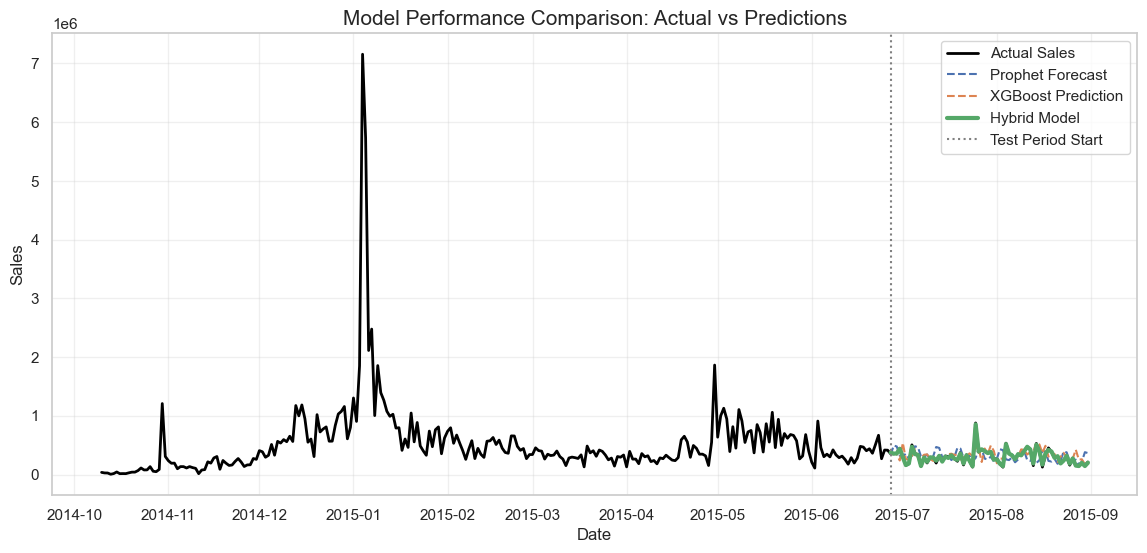

In [61]:
plt.figure(figsize=(14,6))

# Actual sales
plt.plot(ts['date'], ts['sales'], 
         label='Actual Sales', 
         color='black', linewidth=2)

# Prophet predictions
plt.plot(test['date'], prophet_pred, 
         label='Prophet Forecast', 
         linestyle='--')

# XGBoost predictions
plt.plot(test['date'], xgb_pred, 
         label='XGBoost Prediction', 
         linestyle='--')

# Hybrid predictions
plt.plot(test['date'], hybrid_pred, 
         label='Hybrid Model', 
         linewidth=3)

# Mark where forecasting begins
plt.axvline(test['date'].iloc[0], 
            color='gray', 
            linestyle=':', 
            label='Test Period Start')

plt.title("Model Performance Comparison: Actual vs Predictions", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()
